# ARTI308 - Lab 4: Data Quality Assessment & Preprocessing

**Dataset used:** `data.xlsx` — the same student performance dataset used in the previous labs.

This lab applies preprocessing on the student dataset before building machine learning models.

Main tasks:
1. Identify data quality issues.
2. Apply a missing value strategy.
3. Detect and handle outliers using IQR.
4. Normalize numerical features using Min-Max and Z-score.
5. Apply PCA and interpret explained variance.

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

sns.set(style="whitegrid")

## 1. Load Dataset

We load the same dataset used in the first labs: student performance data.

In [2]:
pd.set_option("display.max_columns", None)

df = pd.read_excel("data.xlsx")
df.head(10)

,StudentID,StudyHours,AttendanceRate,SleepHours,AssignmentsCompleted,FinalScore
0,1,2,60,5,4,55
1,2,5,80,7,7,75
2,3,1,50,4,3,45
3,4,6,90,8,8,85
4,5,3,70,6,5,65
5,6,7,95,7,9,92
6,7,4,75,6,6,70
7,8,2,65,5,4,58
8,9,8,98,8,10,96
9,10,5,85,7,7,80


## 2. Data Quality Assessment

We check the dataset structure, column types, missing values, duplicate rows, and general statistics.

In [3]:
print("Dataset shape:", df.shape)
print("\nColumn data types:")
print(df.dtypes)

Dataset shape: (12, 6)

Column data types:
StudentID               int64
StudyHours              int64
AttendanceRate          int64
SleepHours              int64
AssignmentsCompleted    int64
FinalScore              int64
dtype: object


In [4]:
print("Missing values per column:")
print(df.isna().sum())

print("\nNumber of duplicated rows:", df.duplicated().sum())

Missing values per column:
StudentID               0
StudyHours              0
AttendanceRate          0
SleepHours              0
AssignmentsCompleted    0
FinalScore              0
dtype: int64

Number of duplicated rows: 0


In [5]:
df.describe()

,StudentID,StudyHours,AttendanceRate,SleepHours,AssignmentsCompleted,FinalScore
count,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000
mean,6.500000,4.333333,76.333333,6.333333,6.333333,72.416667
std,3.605551,2.188122,15.452763,1.230915,2.188122,15.894300
min,1.000000,1.000000,50.000000,4.000000,3.000000,45.000000
25%,3.750000,2.750000,63.750000,5.750000,4.750000,61.000000
50%,6.500000,4.500000,77.500000,6.500000,6.500000,72.500000
75%,9.250000,6.000000,88.500000,7.000000,8.000000,85.250000
max,12.000000,8.000000,98.000000,8.000000,10.000000,96.000000


### Data Quality Notes

Based on the checks above:
- The dataset has no missing values.
- The dataset has no duplicate rows.
- All columns are numeric, so no type conversion is required.
- `StudentID` is only an identifier and should not be used as a model feature.

## 3. Handling Missing Values

The original dataset does not contain missing values. For learning purposes, artificial missing values are added to `FinalScore`, then handled using **median imputation**.

Median is used because it is more robust than the mean when outliers exist.

In [6]:
df_missing = df.copy()

# Introduce artificial missing values for demonstration
df_missing.loc[0:2, 'FinalScore'] = np.nan

print("Missing values after introducing NaN values:")
print(df_missing.isna().sum())

df_missing.head()

Missing values after introducing NaN values:
StudentID               0
StudyHours              0
AttendanceRate          0
SleepHours              0
AssignmentsCompleted    0
FinalScore              3
dtype: int64


,StudentID,StudyHours,AttendanceRate,SleepHours,AssignmentsCompleted,FinalScore
0,1,2,60,5,4,NaN
1,2,5,80,7,7,NaN
2,3,1,50,4,3,NaN
3,4,6,90,8,8,85.0
4,5,3,70,6,5,65.0


In [7]:
df_imputed = df_missing.copy()

median_final_score = df_imputed['FinalScore'].median()
df_imputed['FinalScore'] = df_imputed['FinalScore'].fillna(median_final_score)

print("Median used for imputation:", median_final_score)
print("\nMissing values after imputation:")
print(df_imputed.isna().sum())

df_imputed.head()

Median used for imputation: 80.0

Missing values after imputation:
StudentID               0
StudyHours              0
AttendanceRate          0
SleepHours              0
AssignmentsCompleted    0
FinalScore              0
dtype: int64


,StudentID,StudyHours,AttendanceRate,SleepHours,AssignmentsCompleted,FinalScore
0,1,2,60,5,4,80.0
1,2,5,80,7,7,80.0
2,3,1,50,4,3,80.0
3,4,6,90,8,8,85.0
4,5,3,70,6,5,65.0


## 4. Handling Outliers Using IQR

Outliers are detected in the target column `FinalScore` using the Interquartile Range method.

Outlier limits:
- Lower Limit = Q1 - 1.5 × IQR
- Upper Limit = Q3 + 1.5 × IQR

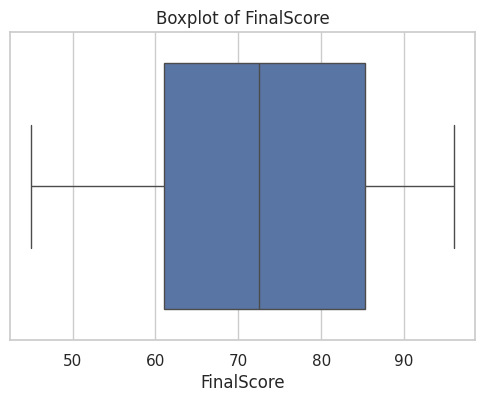

In [8]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['FinalScore'])
plt.title("Boxplot of FinalScore")
plt.show()

In [9]:
Q1 = df['FinalScore'].quantile(0.25)
Q3 = df['FinalScore'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['FinalScore'] < lower) | (df['FinalScore'] > upper)]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower limit:", lower)
print("Upper limit:", upper)
print("Number of outliers:", len(outliers))

outliers

Q1: 61.0
Q3: 85.25
IQR: 24.25
Lower limit: 24.625
Upper limit: 121.625
Number of outliers: 0


,StudentID,StudyHours,AttendanceRate,SleepHours,AssignmentsCompleted,FinalScore


In [10]:
df_no_outliers = df[(df['FinalScore'] >= lower) & (df['FinalScore'] <= upper)].copy()

print("Original shape:", df.shape)
print("After removing outliers:", df_no_outliers.shape)

Original shape: (12, 6)
After removing outliers: (12, 6)


### Outlier Handling Interpretation

If the output shows no outliers, then no records need to be removed. If outliers are found, they can be removed or capped depending on whether they are data errors or valid rare cases.

## 5. Normalization

We normalize the numerical feature columns:
- `StudyHours`
- `AttendanceRate`
- `SleepHours`
- `AssignmentsCompleted`

`StudentID` is excluded because it is an identifier.
`FinalScore` is the target variable, so it is not normalized as an input feature.

In [11]:
feature_cols = ['StudyHours', 'AttendanceRate', 'SleepHours', 'AssignmentsCompleted']

X = df[feature_cols].copy()
y = df['FinalScore'].copy()

X.head()

,StudyHours,AttendanceRate,SleepHours,AssignmentsCompleted
0,2,60,5,4
1,5,80,7,7
2,1,50,4,3
3,6,90,8,8
4,3,70,6,5


### 5.1 Min-Max Normalization

Min-Max normalization scales values between 0 and 1.

In [12]:
minmax_scaler = MinMaxScaler()
X_minmax = pd.DataFrame(
    minmax_scaler.fit_transform(X),
    columns=feature_cols
)

X_minmax.head()

,StudyHours,AttendanceRate,SleepHours,AssignmentsCompleted
0,0.142857,0.208333,0.25,0.142857
1,0.571429,0.625000,0.75,0.571429
2,0.000000,0.000000,0.00,0.000000
3,0.714286,0.833333,1.00,0.714286
4,0.285714,0.416667,0.50,0.285714


### 5.2 Z-Score Standardization

Z-score standardization transforms features so that each feature has a mean close to 0 and standard deviation close to 1.

In [13]:
standard_scaler = StandardScaler()
X_zscore = pd.DataFrame(
    standard_scaler.fit_transform(X),
    columns=feature_cols
)

X_zscore.head()

,StudyHours,AttendanceRate,SleepHours,AssignmentsCompleted
0,-1.113780,-1.103984,-1.131371,-1.113780
1,0.318223,0.247833,0.565685,0.318223
2,-1.591115,-1.779893,-1.979899,-1.591115
3,0.795557,0.923742,1.414214,0.795557
4,-0.636446,-0.428076,-0.282843,-0.636446


In [14]:
print("Means after Z-score standardization:")
print(X_zscore.mean().round(4))

print("\nStandard deviations after Z-score standardization:")
print(X_zscore.std().round(4))

Means after Z-score standardization:
StudyHours              0.0
AttendanceRate          0.0
SleepHours              0.0
AssignmentsCompleted    0.0
dtype: float64

Standard deviations after Z-score standardization:
StudyHours              1.0445
AttendanceRate          1.0445
SleepHours              1.0445
AssignmentsCompleted    1.0445
dtype: float64


## 6. Correlation Check Before PCA

PCA is more useful when features contain overlapping information. A correlation heatmap helps us see relationships between features.

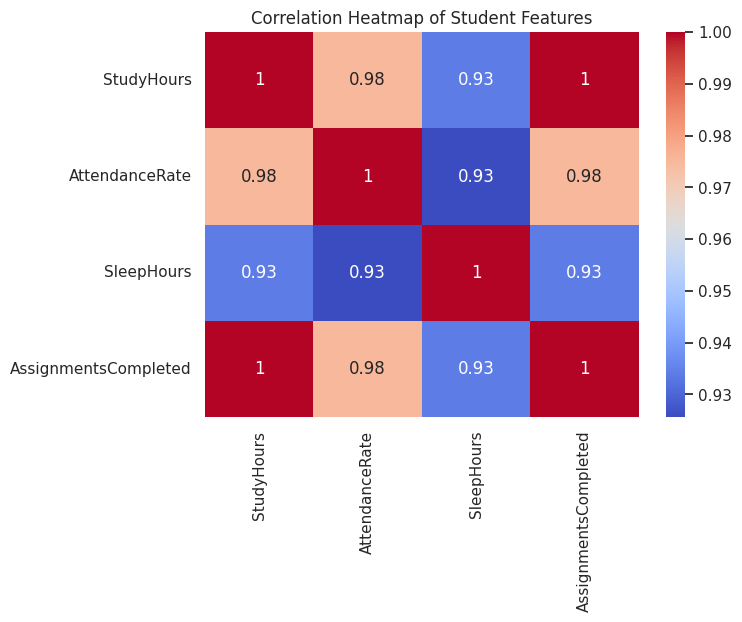

In [15]:
plt.figure(figsize=(7,5))
sns.heatmap(X_zscore.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Student Features")
plt.show()

## 7. PCA

PCA is applied on the standardized feature set because PCA is affected by feature scale.

In [16]:
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_zscore)

pca_df = pd.DataFrame(
    principal_components,
    columns=['PC1', 'PC2']
)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total variance captured by PC1 and PC2:", pca.explained_variance_ratio_.sum())

pca_df.head()

Explained Variance Ratio: [0.96807298 0.02363006]
Total variance captured by PC1 and PC2: 0.9917030396650007


,PC1,PC2
0,-2.231095,-0.044815
1,0.722315,0.243388
2,-3.466813,-0.323541
3,1.958033,0.522114
4,-0.995377,0.233911


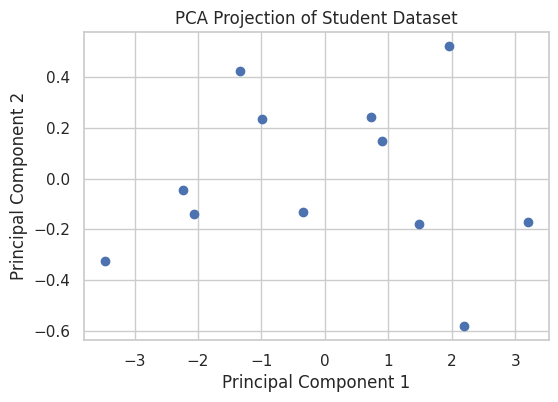

In [17]:
plt.figure(figsize=(6,4))
plt.scatter(pca_df['PC1'], pca_df['PC2'])
plt.title("PCA Projection of Student Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

## Final Interpretation

- The dataset is clean because it has no missing values and no duplicate records.
- Median imputation was demonstrated on artificial missing values in `FinalScore`.
- IQR was used to detect outliers in `FinalScore`.
- Min-Max normalization scaled feature values between 0 and 1.
- Z-score standardization centered features around 0.
- PCA reduced the feature space into two principal components and showed how much variance is captured by these components.

This preprocessing workflow prepares the student dataset for machine learning model training.